## Load Libraries

In [2]:
import pandas as pd
#from fbprophet import Prophet
from prophet import Prophet

c:\Users\grego\OneDrive\Documentos\cursos\curso-series-temporales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Load Data



In [4]:
df = pd.read_csv('./BeerWineLiquor.csv')

In [5]:
df.head()

,date,beer
0,1/1/1992,1509
1,2/1/1992,1541
2,3/1/1992,1597
3,4/1/1992,1675
4,5/1/1992,1822


### Format the Data

In [6]:
df.columns = ['ds','y']

In [7]:
df['ds'] = pd.to_datetime(df['ds'])

## Create and Fit Model

In [9]:
m = Prophet() # esto crea el modelo
m.fit(df) # esto entrena el modelo

21:47:01 - cmdstanpy - INFO - Chain [1] start processing
21:47:01 - cmdstanpy - INFO - Chain [1] done processing


## Pronósticos del futuro

### Paso 1: Crear el dataframe donde colocaremos los resultados



In [10]:
future = m.make_future_dataframe(periods=24,freq = 'MS')

In [11]:
future.head()

,ds
0,1992-01-01
1,1992-02-01
2,1992-03-01
3,1992-04-01
4,1992-05-01


In [12]:
df.head()

,ds,y
0,1992-01-01,1509
1,1992-02-01,1541
2,1992-03-01,1597
3,1992-04-01,1675
4,1992-05-01,1822


In [13]:
df.tail()

,ds,y
319,2018-08-01,4898
320,2018-09-01,4598
321,2018-10-01,4737
322,2018-11-01,5130
323,2018-12-01,6370


In [14]:
future.tail()

,ds
343,2020-08-01
344,2020-09-01
345,2020-10-01
346,2020-11-01
347,2020-12-01



### Paso 2: Calcular los pronósticos y guardarlos en forecast

In [15]:
forecast = m.predict(future)

In [16]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1992-01-01,1763.763820,1132.444097,1464.139488,1763.763820,1763.763820,-461.318276,-461.318276,-461.318276,-461.318276,-461.318276,-461.318276,0.0,0.0,0.0,1302.445544
1,1992-02-01,1766.914160,1184.150974,1501.990778,1766.914160,1766.914160,-426.414880,-426.414880,-426.414880,-426.414880,-426.414880,-426.414880,0.0,0.0,0.0,1340.499281
2,1992-03-01,1769.861253,1427.819527,1746.451579,1769.861253,1769.861253,-178.480729,-178.480729,-178.480729,-178.480729,-178.480729,-178.480729,0.0,0.0,0.0,1591.380524
3,1992-04-01,1773.011594,1401.162204,1742.767247,1773.011594,1773.011594,-196.071714,-196.071714,-196.071714,-196.071714,-196.071714,-196.071714,0.0,0.0,0.0,1576.939880
4,1992-05-01,1776.060310,1646.441638,1978.576951,1776.060310,1776.060310,44.753299,44.753299,44.753299,44.753299,44.753299,44.753299,0.0,0.0,0.0,1820.813610


In [17]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
343,2020-08-01,5199.885791,5084.605260,5414.917844,5188.486330,5211.987104,39.193228,39.193228,39.193228,39.193228,39.193228,39.193228,0.0,0.0,0.0,5239.079018
344,2020-09-01,5215.923160,4918.838494,5238.222657,5203.538422,5228.838584,-134.004608,-134.004608,-134.004608,-134.004608,-134.004608,-134.004608,0.0,0.0,0.0,5081.918552
345,2020-10-01,5231.443196,5013.354922,5352.255520,5217.649844,5245.059512,-43.735507,-43.735507,-43.735507,-43.735507,-43.735507,-43.735507,0.0,0.0,0.0,5187.707688
346,2020-11-01,5247.480565,5173.133624,5508.981499,5232.127854,5261.924390,87.622366,87.622366,87.622366,87.622366,87.622366,87.622366,0.0,0.0,0.0,5335.102931
347,2020-12-01,5263.000600,6171.510375,6506.311955,5246.650639,5278.951540,1070.425457,1070.425457,1070.425457,1070.425457,1070.425457,1070.425457,0.0,0.0,0.0,6333.426057


In [17]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [18]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
336,2020-01-01,4628.375264,4470.249163,4783.351805
337,2020-02-01,4679.316031,4516.376067,4836.014811
338,2020-03-01,4942.252882,4782.622118,5099.214502
339,2020-04-01,4940.699267,4785.033163,5107.725479
340,2020-05-01,5197.044315,5037.538073,5367.806203
341,2020-06-01,5177.448924,5012.360921,5337.733363
342,2020-07-01,5309.517039,5148.513014,5463.084850
343,2020-08-01,5239.079018,5084.605260,5414.917844
344,2020-09-01,5081.918552,4918.838494,5238.222657
345,2020-10-01,5187.707688,5013.354922,5352.255520


### Graficando los pronósticos


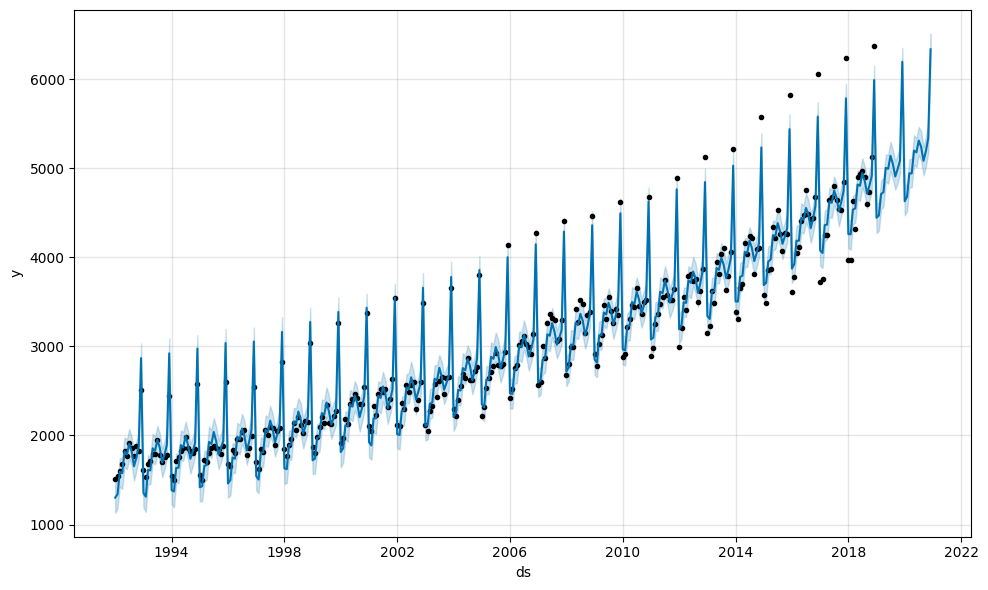

In [19]:
m.plot(forecast);

In [20]:
pd.plotting.register_matplotlib_converters()

(16071.0, 18993.0)

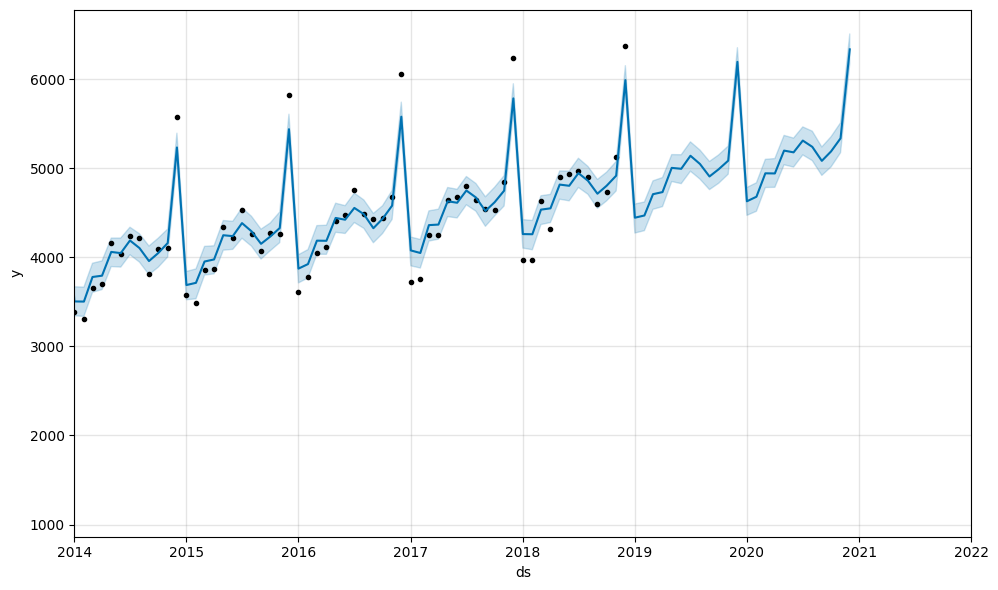

In [21]:
import matplotlib.pyplot as plt
m.plot(forecast)
plt.xlim('2014-01-01','2022-01-01')

<Axes: xlabel='ds'>

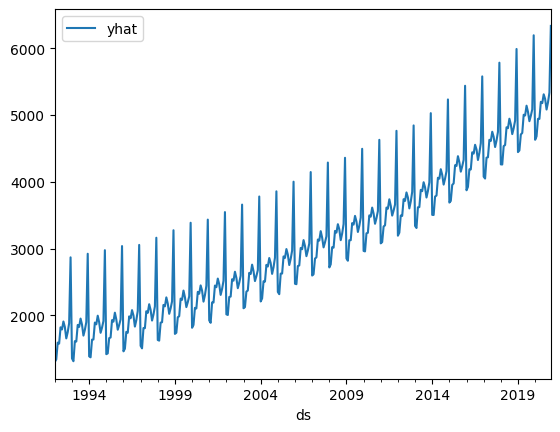

In [22]:
forecast.plot(x='ds',y='yhat')

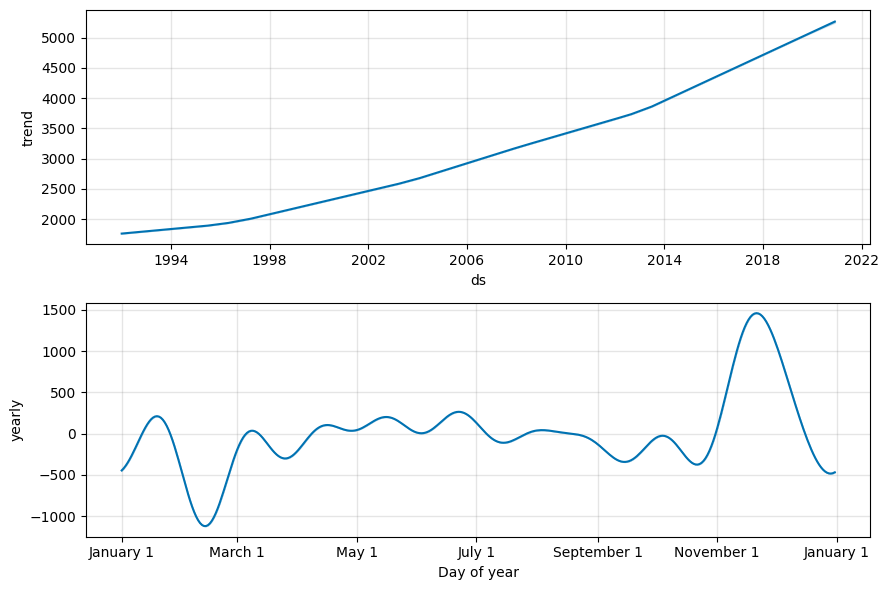

In [23]:
m.plot_components(forecast);
